<h1 style="color:green;font-size:22px;">Function 5 - Black-Box Optimisation</h1>
<h1 style="color:#0000CD;font-size:19px;">Objective and reading guide</h1>

Function 5 is a **four-dimensional** black-box objective on $[0,1]^4$. Its analytical form is unknown, but the challenge describes the function as unimodal. Starting from 20 observations, the goal is to maximise the observed response using 13 sequential evaluations.

For intuition only, the four inputs can be viewed as normalised controls of a chemical process and the output as its yield. This analogy is illustrative rather than a known physical interpretation of the hidden objective.

The historical search is organised into two phases:

1. **Weeks 1–4 — Global RBF-EI search:** Expected Improvement is maximised on the historical $50^4$ Cartesian grid.
2. **Weeks 5–13 — Manual boundary diagnostics:** after repeated improvement toward the upper corner, the remaining evaluations test the corner itself and then probe the nearby boundary structure.

The final section evaluates performance, surrogate robustness, early EI sensitivity, and the strength of the observed boundary evidence.


In [1]:
# Standard libraries
import sys
import warnings
from pathlib import Path

# Numerical computing and data handling
import numpy as np
import pandas as pd

# Scikit-learn
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel

# BBO project root
ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

# BBO project package
from src.config import RANDOM_SEED
from src.data import load_initial_data, extract, update_data, historical_record
from src.acquisition import expected_improvement
from src.search import cartesian_grid, exhaustive_cartesian_search_4d
from src.plotting import plot_pairwise_observations_2d, plot_sequential_query_performance
from src.validation import sequential_performance, kernel_choice_validation

FUNCTION_ID = 5
DIMENSION = 4
INITIAL_OBSERVATIONS = 20
GRID_RESOLUTION = 50
XI = 0.01

warnings.filterwarnings("ignore", category=ConvergenceWarning)


<h1 style="color:#0000CD;font-size:19px;">1. Initial observations</h1>

The experiment begins with **20 observations** in four dimensions. Before fitting a surrogate, the initial sample is inspected for scale, coverage, and the starting incumbent. With only 20 points in $[0,1]^4$, the first search phase remains global rather than imposing a local region.


In [2]:
data = load_initial_data(FUNCTION_ID)
inputs, outputs = extract(data)

initial_inputs = inputs.copy()
initial_outputs = outputs.copy()
initial_best_idx = int(np.argmax(initial_outputs))

print(f"Initial observations: {len(initial_outputs)}")
print(f"Initial best: {initial_outputs[initial_best_idx]:.6f}")
print(f"Initial best location: {initial_inputs[initial_best_idx]}")
print(f"Observed range: {np.ptp(initial_outputs):.6f}")

display(data)


Initial observations: 20
Initial best: 1088.859618
Initial best location: [0.22418902 0.84648049 0.87948418 0.87851568]
Observed range: 1088.746678


,x1,x2,x3,x4,y
0,0.191447,0.038193,0.607418,0.414584,64.443440
1,0.758653,0.536518,0.656000,0.360342,18.301380
2,0.438350,0.804340,0.210245,0.151295,0.112940
3,0.706051,0.534192,0.264243,0.482088,4.210898
4,0.836478,0.193610,0.663893,0.785649,258.370525
5,0.683432,0.118663,0.829046,0.567577,78.434389
6,0.553621,0.667350,0.323806,0.814870,57.571537
7,0.352356,0.322242,0.116979,0.473113,109.571876
8,0.153786,0.729382,0.422598,0.443074,8.847992
9,0.463442,0.630025,0.107906,0.957644,233.223610


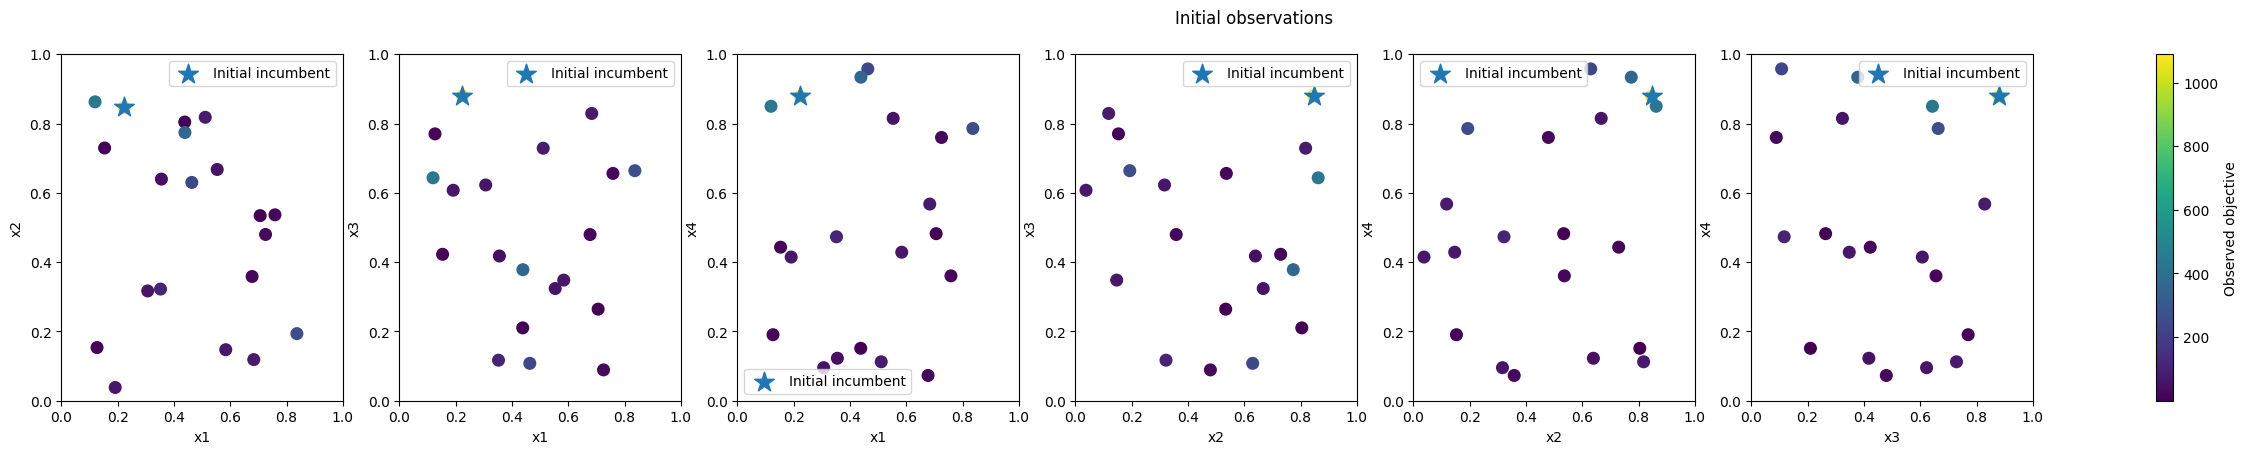

In [3]:
plot_pairwise_observations_2d(initial_inputs, initial_outputs)


**Initial observation.** The best starting response is approximately **1,088.8596**. The initial sample is too sparse to identify the maximiser directly, so a smooth GP-EI search is used to test whether the promising high-coordinate direction persists.


<h1 style="color:#0000CD;font-size:19px;">2. Phase 1: Global RBF-EI search (Weeks 1–4)</h1>

The first four evaluations reproduce the original model-driven strategy:

- **Surrogate:** RBF Gaussian process, initial length scale $0.2$, with the length scale optimised;
- **Acquisition:** Expected Improvement with $\xi=0.01$;
- **Candidate set:** the historical $50^4=6{,}250{,}000$ Cartesian grid over $[0,1]^4$.

Relative to the scale of the observed objective, $\xi=0.01$ is strongly exploitation-oriented. Function 5 is described as unimodal, so continued improvement in one direction provides a reasonable basis for progressively stronger exploitation.

For reproducibility, the Cartesian grid is retained rather than replaced by random or low-discrepancy candidates. The refactor scans the same grid in memory-safe slabs.


In [4]:
def rbf_kernel(initial_scale=0.2):
    """Historical Function 5 GP kernel."""
    return RBF(length_scale=initial_scale) + WhiteKernel(noise_level=1e-6)

query_rows = []

for week in range(1, 5):
    current_inputs, current_outputs = extract(data)
    previous_best = float(current_outputs.max())

    gp = GaussianProcessRegressor(kernel=rbf_kernel(), alpha=1e-10, normalize_y=True,random_state=RANDOM_SEED).fit(current_inputs, current_outputs)

    search = exhaustive_cartesian_search_4d(
        gp,
        resolution=GRID_RESOLUTION,
        best=previous_best,
        xi=XI,
        compute_ei=True,
        compute_ucb=False)

    recorded_point, observed_y = historical_record(FUNCTION_ID, week)
    assert np.allclose(search["ei_point"], recorded_point, atol=5e-6), \
        f"Week {week} does not reproduce the historical EI query."

    query_rows.append({
        "week": week,
        "phase": "Global RBF-EI",
        "decision": "EI-selected",
        **{f"x{i+1}": recorded_point[i] for i in range(DIMENSION)},
        "observed_y": observed_y,
        "previous_incumbent": previous_best,
        "best_so_far": max(previous_best, observed_y),
        "improved_incumbent": observed_y > previous_best})

    data = update_data(data, recorded_point, observed_y)

phase_1_history = pd.DataFrame(query_rows)
display(phase_1_history)


Point added!
Point added!
Point added!
Point added!


,week,phase,decision,x1,x2,x3,x4,observed_y,previous_incumbent,best_so_far,improved_incumbent
0,1,Global RBF-EI,EI-selected,0.285714,0.836735,0.938776,0.897959,1489.609415,1088.859618,1489.609415,True
1,2,Global RBF-EI,EI-selected,0.326531,0.836735,0.938776,0.897959,1500.250566,1489.609415,1500.250566,True
2,3,Global RBF-EI,EI-selected,0.469388,0.877551,1.000000,1.000000,3294.679200,1500.250566,3294.679200,True
3,4,Global RBF-EI,EI-selected,0.734694,1.000000,1.000000,1.000000,5553.031467,3294.679200,5553.031467,True


**Phase result.** All four EI-selected queries improve the incumbent. The first query raises the best value from about **1,088.8596** to **1,489.6094**, supporting continued EI-guided refinement. The subsequent queries reach approximately **1,500.2506**, **3,294.6792**, and **5,553.0315**, while moving progressively toward the upper corner. By Week 4, three coordinates are already at $1$.

This repeated directional improvement motivates a deliberate departure from automatic EI selection: the remaining budget is used to test whether the trend continues to the boundary and to diagnose the local geometry around it.


<h1 style="color:#0000CD;font-size:19px;">3. Phase 2: Manual boundary diagnostics (Weeks 5–13)</h1>

Weeks 5–13 are **manual diagnostic queries**. They preserve the exact logic of the original notebook:

- **Week 5 — upper-corner test:** evaluate $[1,1,1,1]$ to determine whether the repeated EI improvement continues all the way to the boundary;
- **Weeks 6–9 — one-coordinate sensitivity:** move each coordinate individually from $1$ to $0.95$ while holding the other three at the boundary;
- **Week 10 — symmetric inward test:** evaluate $[0.99,0.99,0.99,0.99]$ to test whether the maximiser may lie slightly inside the boundary;
- **Weeks 11–13 — pairwise symmetry tests:** evaluate three representative pairwise perturbations at $0.995$ after the equal one-coordinate responses suggest strong local symmetry.

These points are not acquisition-selected. They are targeted experiments designed to challenge the boundary interpretation before accepting it.


In [5]:
manual_schedule = [
    (5,  [1.000, 1.000, 1.000, 1.000], "Upper-corner test"),
    (6,  [0.950, 1.000, 1.000, 1.000], "One-coordinate inward probe"),
    (7,  [1.000, 1.000, 1.000, 0.950], "One-coordinate inward probe"),
    (8,  [1.000, 1.000, 0.950, 1.000], "One-coordinate inward probe"),
    (9,  [1.000, 0.950, 1.000, 1.000], "One-coordinate inward probe"),
    (10, [0.990, 0.990, 0.990, 0.990], "Symmetric inward probe"),
    (11, [0.995, 0.995, 1.000, 1.000], "Pairwise inward probe"),
    (12, [1.000, 1.000, 0.995, 0.995], "Pairwise inward probe"),
    (13, [1.000, 0.995, 0.995, 1.000], "Pairwise inward probe"),
]

for week, planned_point, decision in manual_schedule:
    current_outputs = extract(data)[1]
    previous_best = float(current_outputs.max())
    recorded_point, observed_y = historical_record(FUNCTION_ID, week)

    if not np.allclose(recorded_point, planned_point, atol=5e-6):
        print( f"⚠️ Week {week}: planned point does not match the historical query.\n"
               f"   Planned:  {np.asarray(planned_point)}\n"
               f"   Recorded: {recorded_point}")

    query_rows.append({
        "week": week,
        "phase": "Manual boundary diagnostics",
        "decision": decision,
        **{f"x{i+1}": recorded_point[i] for i in range(DIMENSION)},
        "observed_y": observed_y,
        "previous_incumbent": previous_best,
        "best_so_far": max(previous_best, observed_y),
        "improved_incumbent": observed_y > previous_best})

    data = update_data(data, recorded_point, observed_y)

query_history = pd.DataFrame(query_rows)
manual_history = query_history.loc[query_history["week"] >= 5].reset_index(drop=True)
inputs, outputs = extract(data)
query_outputs = outputs[INITIAL_OBSERVATIONS:]

display(manual_history)


Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Point added!


,week,phase,decision,x1,x2,x3,x4,observed_y,previous_incumbent,best_so_far,improved_incumbent
0,5,Manual boundary diagnostics,Upper-corner test,1.000,1.000,1.000,1.000,8662.482500,5553.031467,8662.4825,True
1,6,Manual boundary diagnostics,One-coordinate inward probe,0.950,1.000,1.000,1.000,7786.371350,8662.482500,8662.4825,False
2,7,Manual boundary diagnostics,One-coordinate inward probe,1.000,1.000,1.000,0.950,7786.371350,8662.482500,8662.4825,False
3,8,Manual boundary diagnostics,One-coordinate inward probe,1.000,1.000,0.950,1.000,7786.371350,8662.482500,8662.4825,False
4,9,Manual boundary diagnostics,One-coordinate inward probe,1.000,0.950,1.000,1.000,7786.371350,8662.482500,8662.4825,False
5,10,Manual boundary diagnostics,Symmetric inward probe,0.990,0.990,0.990,0.990,7915.738969,8662.482500,8662.4825,False
6,11,Manual boundary diagnostics,Pairwise inward probe,0.995,0.995,1.000,1.000,8471.231482,8662.482500,8662.4825,False
7,12,Manual boundary diagnostics,Pairwise inward probe,1.000,1.000,0.995,0.995,8471.231482,8662.482500,8662.4825,False
8,13,Manual boundary diagnostics,Pairwise inward probe,1.000,0.995,0.995,1.000,8471.231482,8662.482500,8662.4825,False


**Manual-phase result.** Week 5 returns **8,662.4825** at $[1,1,1,1]$, the largest observed value and the largest single improvement of the experiment.

The subsequent probes all remain below the corner:

- the four one-coordinate $0.95$ perturbations each return **7,786.3713**;
- the symmetric $0.99$ perturbation returns **7,915.7390**;
- the three tested pairwise $0.995$ perturbations each return **8,471.2315**.

The equal responses within the one-coordinate and pairwise families provide the original local-symmetry evidence. Together with the lower inward values, they support $[1,1,1,1]$ as the best **observed** configuration while avoiding any claim of a formally proven global optimum.


In [6]:
display(query_history)


,week,phase,decision,x1,x2,x3,x4,observed_y,previous_incumbent,best_so_far,improved_incumbent
0,1,Global RBF-EI,EI-selected,0.285714,0.836735,0.938776,0.897959,1489.609415,1088.859618,1489.609415,True
1,2,Global RBF-EI,EI-selected,0.326531,0.836735,0.938776,0.897959,1500.250566,1489.609415,1500.250566,True
2,3,Global RBF-EI,EI-selected,0.469388,0.877551,1.000000,1.000000,3294.679200,1500.250566,3294.679200,True
3,4,Global RBF-EI,EI-selected,0.734694,1.000000,1.000000,1.000000,5553.031467,3294.679200,5553.031467,True
4,5,Manual boundary diagnostics,Upper-corner test,1.000000,1.000000,1.000000,1.000000,8662.482500,5553.031467,8662.482500,True
5,6,Manual boundary diagnostics,One-coordinate inward probe,0.950000,1.000000,1.000000,1.000000,7786.371350,8662.482500,8662.482500,False
6,7,Manual boundary diagnostics,One-coordinate inward probe,1.000000,1.000000,1.000000,0.950000,7786.371350,8662.482500,8662.482500,False
7,8,Manual boundary diagnostics,One-coordinate inward probe,1.000000,1.000000,0.950000,1.000000,7786.371350,8662.482500,8662.482500,False
8,9,Manual boundary diagnostics,One-coordinate inward probe,1.000000,0.950000,1.000000,1.000000,7786.371350,8662.482500,8662.482500,False
9,10,Manual boundary diagnostics,Symmetric inward probe,0.990000,0.990000,0.990000,0.990000,7915.738969,8662.482500,8662.482500,False


<h1 style="color:#0000CD;font-size:19px;">4. Quantitative Evaluation</h1>

The retrospective evaluation separates four questions:

1. **Performance:** how much did the 13-query budget improve the initial incumbent?
2. **Surrogate robustness:** is the inferred response structure strongly dependent on the historical RBF family?
3. **Early-search sensitivity:** would reasonable RBF initialisation, EI $\xi$, or Cartesian-grid resolution choices materially change the first model-driven decision?
4. **Boundary evidence:** do the observed manual probes quantitatively support the final upper-boundary conclusion?

These diagnostics use only the observations available in the project. They do not reveal the hidden objective at unevaluated points and therefore cannot establish global optimality.


**4.1 - Sequential and query-budget performance**

Each evaluation is compared with the incumbent available immediately before it.


,metric,value
0,Initial incumbent,1088.859618
1,Final best observed,8662.482500
2,Absolute improvement,7573.622882
3,Relative improvement,6.955555
4,Queries improving incumbent,5.000000


,query,query_output,best_so_far,improvement
0,1,1489.609415,1489.609415,400.749797
1,2,1500.250566,1500.250566,10.641151
2,3,3294.679200,3294.679200,1794.428634
3,4,5553.031467,5553.031467,2258.352267
4,5,8662.482500,8662.482500,3109.451033
5,6,7786.371350,8662.482500,0.000000
6,7,7786.371350,8662.482500,0.000000
7,8,7786.371350,8662.482500,0.000000
8,9,7786.371350,8662.482500,0.000000
9,10,7915.738969,8662.482500,0.000000


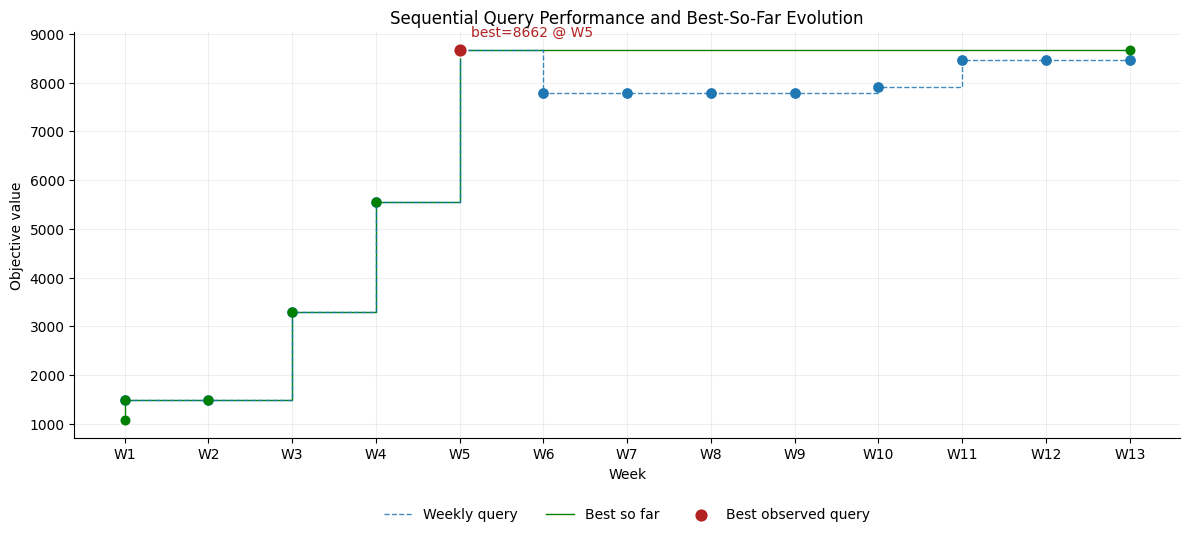

In [7]:
performance, performance_summary = sequential_performance(
    initial_outputs=initial_outputs,
    query_outputs=query_outputs,
)

display(performance_summary)
display(performance)

plot_sequential_query_performance(
    performance,
    FUNCTION_ID,
    yscale="linear",
    plot_type="bar",
)


**Performance result.** The incumbent rises from approximately **1,088.8596** to **8,662.4825**, an absolute gain of about **7,573.6229** and a relative increase of approximately **695.6%** (about **7.96×** the initial incumbent). The first five evaluations improve the incumbent; Weeks 6–13 are deliberately diagnostic and do not replace the Week 5 corner solution.


**4.2 - Surrogate robustness**

The historical model-driven phase used an RBF GP. A Matérn-5/2 alternative is included as a retrospective model-form check using leave-one-out RMSE and Spearman rank correlation on the observed data.


In [8]:
predictive_kernels = {
    "RBF_historical": rbf_kernel(),
    "Matern_52": Matern(length_scale=np.full(DIMENSION, 0.2), nu=2.5)
                 + WhiteKernel(noise_level=1e-6),
}

surrogate_robustness = kernel_choice_validation(
    inputs,
    outputs,
    predictive_kernels,
    alpha=1e-10,
    normalize_y=True,
    n_restarts_optimizer=3,
    random_state=RANDOM_SEED,
)

display(surrogate_robustness)


,kernel,LOOCV_RMSE,Spearman_rank_correlation
0,RBF_historical,302.086705,0.856450
1,Matern_52,279.375724,0.883387


**Interpretation.** This is a robustness check, not an attempt to rewrite the historical strategy after seeing the final data. Similar predictive ranking across the two smooth kernels would support the stability of the inferred high-value region; a material difference should instead be reported as model-form uncertainty.


**4.3 - Early EI decision sensitivity**

Week 1 is the cleanest state for sensitivity analysis because it precedes sequential feedback. Three researcher-controlled choices are tested: the RBF starting length scale, the EI exploration parameter $\xi$, and the Cartesian-grid resolution.


In [9]:
# RBF initialisation sensitivity
initialisation_rows = []
for initial_scale in [0.05, 0.10, 0.20, 0.40]:
    gp = GaussianProcessRegressor(
        kernel=rbf_kernel(initial_scale),
        alpha=1e-10,
        normalize_y=True,
        random_state=RANDOM_SEED,
    ).fit(initial_inputs, initial_outputs)

    initialisation_rows.append({
        "initial_length_scale": initial_scale,
        "fitted_length_scale": float(gp.kernel_.k1.length_scale),
        "fitted_noise_level": float(gp.kernel_.k2.noise_level),
        "log_marginal_likelihood": gp.log_marginal_likelihood_value_})

display(pd.DataFrame(initialisation_rows))

# Common Week 1 GP
week_1_gp = GaussianProcessRegressor(
    kernel=rbf_kernel(),
    alpha=1e-10,
    normalize_y=True,
    random_state=RANDOM_SEED,
).fit(initial_inputs, initial_outputs)

# EI xi sensitivity on a common 25^4 grid
X_xi = cartesian_grid(dimension=DIMENSION, points_per_axis=25)
mu, sigma = week_1_gp.predict(X_xi, return_std=True)

xi_rows = []
for xi in [0.0, 0.01, 0.1, 1.0, 10.0]:
    scores = expected_improvement(
        mu, sigma, best=float(initial_outputs.max()), xi=xi)
    candidate = X_xi[np.argmax(scores)]
    xi_rows.append({
        "xi": xi,
        "candidate": np.round(candidate, 6).tolist(),
        "EI_max": float(scores.max())})

display(pd.DataFrame(xi_rows))

# Cartesian-grid sensitivity with the historical xi
historical_week_1, _ = historical_record(FUNCTION_ID, 1)
grid_rows = []
for resolution in [15, 25, 35, 50]:
    search = exhaustive_cartesian_search_4d(
        week_1_gp,
        resolution=resolution,
        best=float(initial_outputs.max()),
        xi=XI,
        compute_ei=True,
        compute_ucb=False)
    
    candidate = search["ei_point"]
    grid_rows.append({
        "resolution": resolution,
        "n_candidates": search["n_candidates"],
        "candidate": np.round(candidate, 6).tolist(),
        "distance_to_historical_week_1": float(
            np.linalg.norm(candidate - historical_week_1))})

display(pd.DataFrame(grid_rows))


,initial_length_scale,fitted_length_scale,fitted_noise_level,log_marginal_likelihood
0,0.05,0.038988,0.00001,-28.378771
1,0.10,0.268947,0.00001,-26.665958
2,0.20,0.268947,0.00001,-26.665958
3,0.40,0.000010,0.00001,-28.378771


,xi,candidate,EI_max
0,0.00,"[0.291667, 0.833333, 0.958333, 0.916667]",44.946586
1,0.01,"[0.291667, 0.833333, 0.958333, 0.916667]",44.940387
2,0.10,"[0.291667, 0.833333, 0.958333, 0.916667]",44.884616
3,1.00,"[0.291667, 0.833333, 0.958333, 0.916667]",44.329068
4,10.00,"[0.291667, 0.833333, 0.958333, 0.916667]",38.991512


,resolution,n_candidates,candidate,distance_to_historical_week_1
0,15,50625,"[0.285714, 0.857143, 0.928571, 0.928571]",3.818029e-02
1,25,390625,"[0.291667, 0.833333, 0.958333, 0.916667]",2.791902e-02
2,35,1500625,"[0.264706, 0.852941, 0.941176, 0.911765]",3.000568e-02
3,50,6250000,"[0.285714, 0.836735, 0.938776, 0.897959]",6.700594e-07


**Interpretation.** The initial-length-scale check tests whether GP fitting is driven by an arbitrary starting value. The $\xi$ check asks whether $0.01$ behaves effectively like near-zero EI on Function 5's response scale. The grid check separates coordinate-level discretisation from a genuine change of search region: the exact argmax may move on coarser lattices without implying a qualitatively different decision.


**4.4 - Quantifying the boundary evidence**

The final diagnostic measures the approach to the upper corner during Weeks 1–5 and summarises the response of each manual probe family.


In [10]:
corner = np.ones(DIMENSION)
coordinate_columns = [f"x{i+1}" for i in range(DIMENSION)]

trajectory = query_history.loc[query_history["week"] <= 5].copy()
trajectory["distance_to_upper_corner"] = np.linalg.norm(
    trajectory[coordinate_columns].to_numpy() - corner,
    axis=1,
)
display(trajectory[["week", "observed_y", "best_so_far", "distance_to_upper_corner"]])

family_map = {
    5: "upper corner",
    6: "single-coordinate 0.95",
    7: "single-coordinate 0.95",
    8: "single-coordinate 0.95",
    9: "single-coordinate 0.95",
    10: "all-coordinate 0.99",
    11: "pairwise 0.995",
    12: "pairwise 0.995",
    13: "pairwise 0.995"}

boundary_value = float(query_history.loc[query_history["week"] == 5, "observed_y"].iloc[0])
local_diagnostics = query_history.loc[query_history["week"] >= 5, ["week", "observed_y"]].copy()
local_diagnostics["probe_family"] = local_diagnostics["week"].map(family_map)
local_diagnostics["gap_to_corner"] = local_diagnostics["observed_y"] - boundary_value

boundary_summary = (
    local_diagnostics
    .groupby("probe_family", sort=False)
    .agg(
        n=("observed_y", "size"),
        mean_y=("observed_y", "mean"),
        std_y=("observed_y", "std"),
        mean_gap_to_corner=("gap_to_corner", "mean"))
    .fillna(0.0)
    .reset_index())

display(local_diagnostics)
display(boundary_summary)


,week,observed_y,best_so_far,distance_to_upper_corner
0,1,1489.609415,1489.609415,0.742308
1,2,1500.250566,1500.250566,0.703119
2,3,3294.679200,3294.679200,0.544557
3,4,5553.031467,5553.031467,0.265306
4,5,8662.482500,8662.482500,0.000000


,week,observed_y,probe_family,gap_to_corner
4,5,8662.482500,upper corner,0.000000
5,6,7786.371350,single-coordinate 0.95,-876.111150
6,7,7786.371350,single-coordinate 0.95,-876.111150
7,8,7786.371350,single-coordinate 0.95,-876.111150
8,9,7786.371350,single-coordinate 0.95,-876.111150
9,10,7915.738969,all-coordinate 0.99,-746.743531
10,11,8471.231482,pairwise 0.995,-191.251018
11,12,8471.231482,pairwise 0.995,-191.251018
12,13,8471.231482,pairwise 0.995,-191.251018


,probe_family,n,mean_y,std_y,mean_gap_to_corner
0,upper corner,1,8662.482500,0.0,0.000000
1,single-coordinate 0.95,4,7786.371350,0.0,-876.111150
2,all-coordinate 0.99,1,7915.738969,0.0,-746.743531
3,pairwise 0.995,3,8471.231482,0.0,-191.251018


**Boundary result.** The first five evaluations combine increasing objective values with movement toward $[1,1,1,1]$. Every tested inward perturbation is lower than the corner, while the repeated one-coordinate and pairwise probes return identical values within their respective families. This provides consistent local evidence that the objective increases toward the upper boundary in the tested neighbourhood.


<h1 style="color:#0000CD;font-size:19px;">5. Conclusion and limitations</h1>

Function 5 improves the initial incumbent from approximately **1,088.8596** to **8,662.4825** within the 13-query budget, a relative increase of about **695.6%** (approximately **7.96×** the starting incumbent).

The historical search has a concise two-phase interpretation:

- **Weeks 1–4:** global RBF-EI produces four consecutive improvements and moves decisively toward the upper boundary;
- **Weeks 5–13:** manual diagnostics first test the corner and then challenge that solution with one-coordinate, symmetric, and pairwise inward perturbations.

The best observed configuration is therefore **$[1,1,1,1]$**. The manual diagnostics support this conclusion locally, including strong symmetry across the tested coordinate perturbations, but they do not mathematically prove the global maximum. Function 5 remains a black-box objective and only a finite set of configurations was evaluated.
